<a href="https://colab.research.google.com/github/Nadaramadan1/Assignment_Week-2/blob/main/Task%3A%20Build%20an%20Automated%20Image%20Preprocessing%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

In [3]:
images = {}

uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_COLOR)
    images[filename] = img

print(f"Uploaded {len(images)} images")

Saving alexander-lunyov-Hdzn_gIdh1o-unsplash.jpg to alexander-lunyov-Hdzn_gIdh1o-unsplash.jpg
Uploaded 1 images


In [4]:
def preprocess(img):
    # Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # CLAHE
    clahe = cv2.createCLAHE(2.0, (8,8))
    enhanced = clahe.apply(gray)

    # Gaussian Blur
    blurred = cv2.GaussianBlur(enhanced, (5,5), 0)

    # Otsu Threshold
    _, thresh = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Morphological Opening
    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    return gray, cleaned


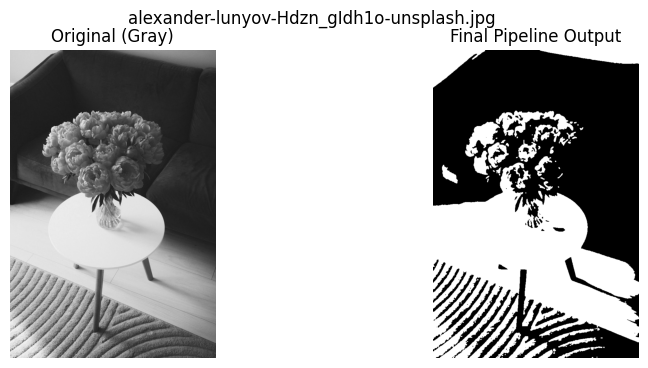

Done processing all images ✔


In [5]:
output_dir = "processed_output"
os.makedirs(output_dir, exist_ok=True)

for name, img in images.items():

    gray, result = preprocess(img)

    # Save output
    cv2.imwrite(f"{output_dir}/processed_{name}", result)

    # Display comparison
    plt.figure(figsize=(10,4))
    plt.suptitle(name)

    plt.subplot(1,2,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Original (Gray)")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(result, cmap='gray')
    plt.title("Final Pipeline Output")
    plt.axis("off")

    plt.show()

print("Done processing all images ✔")